<a href="https://colab.research.google.com/github/NadiiaIvashchuk/DTA_2026/blob/main/project_store_sales_analysis/store_sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Аналіз продажів магазину**

## **Вхідний дата-сет(дані)**

In [2]:
# Запусти цей блок, щоб отримати датасет
import pandas as pd
import numpy as np

np.random.seed(42)
n = 300

categories = ['Молочне', 'Хліб та випічка', 'М\'ясо та риба', 'Овочі та фрукти', 'Напої']
products = {
    'Молочне':          ['Молоко 1л', 'Кефір 0.5л', 'Сир кисломолочний', 'Масло вершкове', 'Йогурт'],
    'Хліб та випічка':  ['Хліб білий', 'Батон', 'Булочка', 'Хліб житній', 'Круасан'],
    'М\'ясо та риба':   ['Куряче філе', 'Свинина', 'Ковбаса', 'Риба хек', 'Сосиски'],
    'Овочі та фрукти':  ['Картопля', 'Морква', 'Яблука', 'Банани', 'Помідори'],
    'Напої':            ['Вода 1.5л', 'Сік апельсиновий', 'Чай', 'Кава мелена', 'Лимонад'],
}
prices = {
    'Молоко 1л': 38, 'Кефір 0.5л': 22, 'Сир кисломолочний': 55, 'Масло вершкове': 95, 'Йогурт': 30,
    'Хліб білий': 28, 'Батон': 25, 'Булочка': 12, 'Хліб житній': 32, 'Круасан': 18,
    'Куряче філе': 165, 'Свинина': 210, 'Ковбаса': 145, 'Риба хек': 120, 'Сосиски': 98,
    'Картопля': 20, 'Морква': 15, 'Яблука': 45, 'Банани': 52, 'Помідори': 60,
    'Вода 1.5л': 18, 'Сік апельсиновий': 68, 'Чай': 85, 'Кава мелена': 155, 'Лимонад': 35,
}

chosen_cats = np.random.choice(categories, n, p=[0.25, 0.20, 0.20, 0.20, 0.15])
chosen_products = [np.random.choice(products[c]) for c in chosen_cats]

df_origin = pd.DataFrame({
    'transaction_id': range(1001, 1001 + n),
    'date':           pd.to_datetime(
                          np.random.choice(pd.date_range('2024-03-01', '2024-03-31'), n)
                      ),
    'hour':           np.random.choice(range(8, 21), n, p=[0.04,0.06,0.08,0.10,0.12,0.12,0.11,0.10,0.09,0.08,0.06,0.04,0.00]),
    'category':       chosen_cats,
    'product':        chosen_products,
    'quantity':       np.random.randint(1, 6, n),
    'price_uah':      [prices[p] for p in chosen_products],
    'customer_age':   np.random.randint(18, 70, n),
    'payment':        np.random.choice(['Готівка', 'Картка', 'Телефон'], n, p=[0.35, 0.50, 0.15]),
})


In [3]:
df = df_origin.copy()

In [4]:
df

,transaction_id,date,hour,category,product,quantity,price_uah,customer_age,payment
0,1001,2024-03-17,17,Хліб та випічка,Круасан,4,18,28,Готівка
1,1002,2024-03-13,14,Напої,Кава мелена,3,155,40,Картка
2,1003,2024-03-01,18,Овочі та фрукти,Яблука,1,45,43,Картка
3,1004,2024-03-02,8,М'ясо та риба,Риба хек,3,120,51,Готівка
4,1005,2024-03-09,19,Молочне,Йогурт,5,30,63,Картка
...,...,...,...,...,...,...,...,...,...
295,1296,2024-03-08,10,М'ясо та риба,Сосиски,4,98,48,Готівка
296,1297,2024-03-05,13,Овочі та фрукти,Морква,5,15,28,Телефон
297,1298,2024-03-04,11,Молочне,Молоко 1л,3,38,27,Картка
298,1299,2024-03-24,14,М'ясо та риба,Ковбаса,1,145,20,Готівка


### Блок 1 - Перше знайомство з даними

*   Listeneintrag
*   Listeneintrag



In [5]:
print(df.head(7))

   transaction_id       date  hour         category         product  quantity  \
0            1001 2024-03-17    17  Хліб та випічка         Круасан         4   
1            1002 2024-03-13    14            Напої     Кава мелена         3   
2            1003 2024-03-01    18  Овочі та фрукти          Яблука         1   
3            1004 2024-03-02     8    М'ясо та риба        Риба хек         3   
4            1005 2024-03-09    19          Молочне          Йогурт         5   
5            1006 2024-03-03    13          Молочне      Кефір 0.5л         3   
6            1007 2024-03-31    15          Молочне  Масло вершкове         2   

   price_uah  customer_age  payment  
0         18            28  Готівка  
1        155            40   Картка  
2         45            43   Картка  
3        120            51  Готівка  
4         30            63   Картка  
5         22            51   Картка  
6         95            46  Телефон  


In [6]:
df.head(7) # display(df.head(7))

,transaction_id,date,hour,category,product,quantity,price_uah,customer_age,payment
0,1001,2024-03-17,17,Хліб та випічка,Круасан,4,18,28,Готівка
1,1002,2024-03-13,14,Напої,Кава мелена,3,155,40,Картка
2,1003,2024-03-01,18,Овочі та фрукти,Яблука,1,45,43,Картка
3,1004,2024-03-02,8,М'ясо та риба,Риба хек,3,120,51,Готівка
4,1005,2024-03-09,19,Молочне,Йогурт,5,30,63,Картка
5,1006,2024-03-03,13,Молочне,Кефір 0.5л,3,22,51,Картка
6,1007,2024-03-31,15,Молочне,Масло вершкове,2,95,46,Телефон


In [7]:
df["total_uah"] = df.quantity * df.price_uah
df.total_uah

,total_uah
0,72
1,465
2,45
3,360
4,150
...,...
295,392
296,75
297,114
298,145


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  300 non-null    int64         
 1   date            300 non-null    datetime64[ns]
 2   hour            300 non-null    int64         
 3   category        300 non-null    object        
 4   product         300 non-null    object        
 5   quantity        300 non-null    int64         
 6   price_uah       300 non-null    int64         
 7   customer_age    300 non-null    int64         
 8   payment         300 non-null    object        
 9   total_uah       300 non-null    int64         
dtypes: datetime64[ns](1), int64(6), object(3)
memory usage: 23.6+ KB


In [9]:
df.dtypes

,0
transaction_id,int64
date,datetime64[ns]
hour,int64
category,object
product,object
quantity,int64
price_uah,int64
customer_age,int64
payment,object
total_uah,int64


In [10]:
print(f"Розмір: {df.shape[0]} рядків x {df.shape[1]} стовпців")

Розмір: 300 рядків x 10 стовпців


1.2.Дізнайся розмір таблиці (рядки × стовпці).

In [11]:
df.shape

(300, 10)

In [12]:
print("Типи даних:")
display(df.dtypes)

Типи даних:


,0
transaction_id,int64
date,datetime64[ns]
hour,int64
category,object
product,object
quantity,int64
price_uah,int64
customer_age,int64
payment,object
total_uah,int64


1.4.Перевір, чи є пропущені значення.

In [13]:
df.isna().sum() # df.isna = df.isnull()

,0
transaction_id,0
date,0
hour,0
category,0
product,0
quantity,0
price_uah,0
customer_age,0
payment,0
total_uah,0


1.5.Виведи основну статистику (describe) для числових стовпців.

In [14]:
print("Статистика: \n")
df.describe().round(2)

Статистика: 



,transaction_id,date,hour,quantity,price_uah,customer_age,total_uah
count,300.00,300,300.00,300.00,300.00,300.0,300.00
mean,1150.50,2024-03-16 02:14:24,13.72,2.97,63.45,43.0,186.97
min,1001.00,2024-03-01 00:00:00,8.00,1.00,12.00,18.0,12.00
25%,1075.75,2024-03-08 00:00:00,12.00,2.00,22.00,31.0,60.00
50%,1150.50,2024-03-16 12:00:00,14.00,3.00,38.00,42.5,120.00
75%,1225.25,2024-03-24 00:00:00,16.00,4.00,95.75,55.0,256.25
max,1300.00,2024-03-31 00:00:00,19.00,5.00,210.00,69.0,840.00
std,86.75,NaN,2.74,1.44,51.68,14.6,180.27


** ВИСНОВОК **:  
Датасет містить інформацію про 300 транзакцій, 10 стовпців,   
пропушених значень немає.  
Середня сума чеку - 186.97 грн.  
Мінімальний чек - 12.00 грн. ().
Максимальний чек - 840.00 грн.().  
Підозрілих даних не виявлено.



###### Розбір

######### **Персентилі**:
```
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
1% - min -> 1
25% - (2 + 3) / 2 -> 2.5
50% - median -> (5 + 6) / 2 -> 5.5
75% - 8
100% - max -> 10
```

######### STD:
```
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1000]
mean == 143.71
10.57 - 1 = 9.57
...
|10.57 - 20| = 9.43
```
mediana = 5.5

### Блок 2 - Фільтрація та відбір

2.1.**Відбери всі покупки категорії «М'ясо та риба»**

In [15]:
df[df["category"] == "М'ясо та риба"].head()

,transaction_id,date,hour,category,product,quantity,price_uah,customer_age,payment,total_uah
3,1004,2024-03-02,8,М'ясо та риба,Риба хек,3,120,51,Готівка,360
8,1009,2024-03-21,15,М'ясо та риба,Ковбаса,2,145,34,Картка,290
17,1018,2024-03-06,14,М'ясо та риба,Куряче філе,3,165,69,Картка,495
20,1021,2024-03-23,9,М'ясо та риба,Куряче філе,3,165,64,Телефон,495
24,1025,2024-03-10,14,М'ясо та риба,Свинина,4,210,28,Картка,840


In [16]:
meat_fish = df[df["category"] == "М'ясо та риба"]
print(f'У категорії "Мясо та риба": {len(meat_fish)} транзакцій')

У категорії "Мясо та риба": 61 транзакцій


2.2.Знайди транзакції, де сума (total_uah) перевищує 500 грн

In [17]:
big = df[df["total_uah"] > 500]
print(f"Покупки > 500 грн.: {len(big)}\n")
#print(big[["product", "quantity", "total_uah"]].head())
display(big[["product", "quantity", "total_uah"]].head())

Покупки > 500 грн.: 17



,product,quantity,total_uah
24,Свинина,4,840
28,Куряче філе,4,660
81,Ковбаса,4,580
89,Риба хек,5,600
93,Свинина,3,630


Відсоток великих покупок

In [18]:
pct_big = len(big) / len(df) * 100
#round(pct_big, 1)
print(f"Частка покупок > 500: {pct_big:.1f}%")

Частка покупок > 500: 5.7%


In [19]:
for cat in big.category.unique():
  print(f"{cat} - {big[big["category"] == cat].count()}")

М'ясо та риба - transaction_id    14
date              14
hour              14
category          14
product           14
quantity          14
price_uah         14
customer_age      14
payment           14
total_uah         14
dtype: int64
Напої - transaction_id    3
date              3
hour              3
category          3
product           3
quantity          3
price_uah         3
customer_age      3
payment           3
total_uah         3
dtype: int64


Відбери покупки, зроблені карткою (payment == 'Картка'), кількістю більше 2 одиниць.

In [20]:
card_mult = df[(df["payment"] == "Картка") & (df["quantity"] > 2)]

print("Картка + кількість > 2: ", len(card_mult), "\n")

card_mult.head()

Картка + кількість > 2:  92 



,transaction_id,date,hour,category,product,quantity,price_uah,customer_age,payment,total_uah
1,1002,2024-03-13,14,Напої,Кава мелена,3,155,40,Картка,465
4,1005,2024-03-09,19,Молочне,Йогурт,5,30,63,Картка,150
5,1006,2024-03-03,13,Молочне,Кефір 0.5л,3,22,51,Картка,66
10,1011,2024-03-23,13,Молочне,Сир кисломолочний,5,55,30,Картка,275
17,1018,2024-03-06,14,М'ясо та риба,Куряче філе,3,165,69,Картка,495


2.4.Знайди всі покупки покупців молодше 25 років.

In [21]:
young = df[df["customer_age"] < 25]
print(f"покупців молодше 25 років: {len(young)} \n")
young.head()

покупців молодше 25 років: 36 



,transaction_id,date,hour,category,product,quantity,price_uah,customer_age,payment,total_uah
7,1008,2024-03-01,17,Напої,Сік апельсиновий,1,68,21,Готівка,68
19,1020,2024-03-21,16,Хліб та випічка,Круасан,1,18,19,Готівка,18
26,1027,2024-03-19,13,Молочне,Йогурт,3,30,20,Готівка,90
36,1037,2024-03-04,14,Хліб та випічка,Круасан,1,18,23,Телефон,18
38,1039,2024-03-01,10,Овочі та фрукти,Помідори,1,60,22,Готівка,60


2.5. Скільки унікальних товарів є в датасеті?

In [22]:
n_unique = df["product"].nunique()
#n_unique

pr_unique = df["product"].unique()
#pr_unique

print(f"Кількість унікальних товарів є в датасеті: {n_unique} \n")
print(f"Назви унікальних товарів є в датасеті: {pr_unique} \n")

Кількість унікальних товарів є в датасеті: 25 

Назви унікальних товарів є в датасеті: [np.str_('Круасан') np.str_('Кава мелена') np.str_('Яблука')
 np.str_('Риба хек') np.str_('Йогурт') np.str_('Кефір 0.5л')
 np.str_('Масло вершкове') np.str_('Сік апельсиновий') np.str_('Ковбаса')
 np.str_('Картопля') np.str_('Сир кисломолочний') np.str_('Морква')
 np.str_('Куряче філе') np.str_('Хліб житній') np.str_('Батон')
 np.str_('Хліб білий') np.str_('Свинина') np.str_('Сосиски')
 np.str_('Молоко 1л') np.str_('Помідори') np.str_('Лимонад')
 np.str_('Булочка') np.str_('Банани') np.str_('Вода 1.5л') np.str_('Чай')] 



Висновок

```
Близько 1/2 покупок оплачено карткою, з яких 1/3 - більше двох товарів у чеку.  
5.7% транзакцій перевищують  чек у розмірі 500 грн., здійснені у категорії "Мясо та риба".

12% покупців - до 25 років
```



### Блок 3 - Групування та агрегація

3.1. Підрахуй загальний виторг по кожній категорії. Відсортуй за спаданням.

In [23]:
#revenue_by_cat =
df.groupby("category")["total_uah"].sum().sort_values(ascending=False)

,total_uah
category,
М'ясо та риба,25223
Напої,10389
Молочне,10075
Овочі та фрукти,6270
Хліб та випічка,4134


In [24]:
df.groupby("category").agg({
    "total_uah": "sum",
    "transaction_id": "count",
    "quantity": "sum"
}).sort_values(by=["total_uah", "transaction_id"], ascending=False)



,total_uah,transaction_id,quantity
category,,,
М'ясо та риба,25223,61,186
Напої,10389,48,129
Молочне,10075,80,242
Овочі та фрукти,6270,55,158
Хліб та випічка,4134,56,177


3.2.Знайди топ-5 товарів за кількістю проданих одиниць (сума quantity).

In [25]:
#top_products =
df.groupby("product")["quantity"].sum().sort_values(ascending=False).head(5)
print(f"топ-5 товарів за кількістю проданих одиниць: {df.groupby("product")["quantity"].sum().sort_values(ascending=False).head(5)}")

топ-5 товарів за кількістю проданих одиниць: product
Кефір 0.5л           63
Сосиски              61
Йогурт               57
Сир кисломолочний    54
Риба хек             48
Name: quantity, dtype: int64


3.3.Порівняй середню суму покупки для різних способів оплати

In [26]:
df.groupby("payment")["total_uah"].mean().round(2)

,total_uah
payment,
Готівка,175.16
Картка,205.26
Телефон,144.82


3.4. Згрупуй по hour - знайди, в які години відбувається найбільше транзакцій.

In [27]:
df.groupby("hour").size()

,0
hour,
8,7
9,11
10,23
11,30
12,30
13,41
14,44
15,27
16,32


In [28]:
df.groupby("hour")["hour"].count()

,hour
hour,
8,7
9,11
10,23
11,30
12,30
13,41
14,44
15,27
16,32


In [29]:
df["hour"].value_counts() #best design for this task
print(f"в які години відбувається найбільше транзакцій: {df["hour"].value_counts()}")

в які години відбувається найбільше транзакцій: hour
14    44
13    41
16    32
12    30
11    30
15    27
17    26
10    23
18    19
9     11
19    10
8      7
Name: count, dtype: int64


3.5.Знайди день місяця з найвищим виторгом.

In [30]:
df["day"] = df["date"].dt.day
best_day = df.groupby("day")["total_uah"].sum().idxmax()
best_revenue = df.groupby("day")["total_uah"].sum().max()
print(f"Best day: {best_day} March - {best_revenue:.2f} uah")
#df.groupby("date")["total_uah"].sum().sort_values(ascending=False).head(1)

Best day: 2 March - 3371.00 uah


Висновок


```
Найбільший виторг приносить категорія "М'ясо та риба" (висока ціна).
Найчастіше купують - молочну продукцію, особливо кефір і йогурт.
Пікові години торгівлі - з 13 до 14 години, проте приріст клієнтів починається з 11:00
Найпоширеніший метод оплати - картка (мають в середньому більший чек)

```



### Блок 4 - Нові стовпці та трансформація

4.1.Додай стовпець revenue_share - частка виторгу кожної транзакції від загального виторгу (у відсотках).

In [31]:
total_revenue = df.total_uah.sum()
df["revenue_share"] = (df.total_uah / total_revenue * 100).round(4)
df[["product", "total_uah", "revenue_share"]].head()

,product,total_uah,revenue_share
0,Круасан,72,0.1284
1,Кава мелена,465,0.8290
2,Яблука,45,0.0802
3,Риба хек,360,0.6418
4,Йогурт,150,0.2674


4.2.Додай стовпець age_group:
```
'Молодь' - до 30 років
'Середній вік' - 30–50 років
'Старші' - понад 50 років
```

In [32]:
df['age_group'] = pd.cut(
    df['customer_age'],
    bins=[0, 30, 50, 100],
    labels={'Молодь', 'Середній вік', 'Старші'},
    right=False # права границя - не включно [0, 30), [30, 50), [50, 100)
)

print("Розроділ по вікових групах: \n")
df.age_group.value_counts()

Розроділ по вікових групах: 



,count
age_group,
Середній вік,120
Старші,111
Молодь,69


4.3. Додай стовпець weekday - день тижня з колонки date.

In [33]:
df["weekday"] = df.date.dt.day_name()
df.weekday.value_counts()

,count
weekday,
Sunday,55
Saturday,51
Friday,48
Tuesday,43
Wednesday,35
Monday,35
Thursday,33


4.4.Додай булевий стовпець is_big_purchase - True, якщо total_uah > 300

In [34]:
df["is_big_purchase"] = df.total_uah > 300
pct = df["is_big_purchase"].mean() * 100
print(f"Частка \'великих\' покупок(> 300): {pct:.1f}%")

Частка 'великих' покупок(> 300): 19.3%


In [35]:
print("Середній чек по вікових групах та кільість великих покупок:")

df.groupby("age_group", observed=False).agg({
    "total_uah": "mean",
    "is_big_purchase": "sum"
}).round(2)


Середній чек по вікових групах та кільість великих покупок:


,total_uah,is_big_purchase
age_group,,
Молодь,157.72,9
Середній вік,196.61,28
Старші,194.73,21


Питання: Яка вікова група робить найбільше покупок? Скільки % покупок є «великими»?

### Блок 5 - Візуалізація

In [36]:
df.columns

Index(['transaction_id', 'date', 'hour', 'category', 'product', 'quantity',
       'price_uah', 'customer_age', 'payment', 'total_uah', 'day',
       'revenue_share', 'age_group', 'weekday', 'is_big_purchase'],
      dtype='object')

5.1.Стовпчаста діаграма - виторг по категоріях.

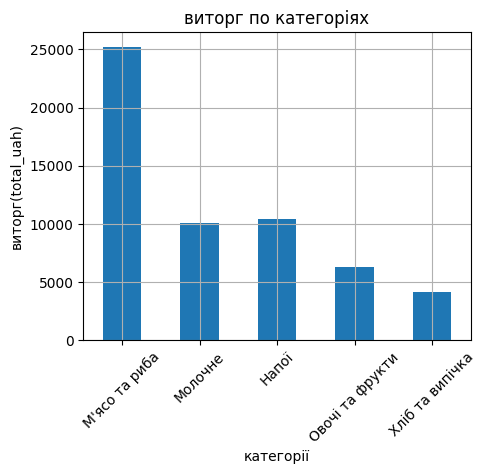

In [37]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(5, 4))
#df.category.value_counts().plot(kind='bar')
df.groupby("category")["total_uah"].sum().plot(kind='bar')
plt.title("виторг по категоріях")
plt.xlabel("категорії")
plt.ylabel("виторг(total_uah)")
plt.xticks(rotation=45)
plt.grid()
plt.show()

5.2.Горизонтальна стовпчаста - топ-10 товарів за виторгом

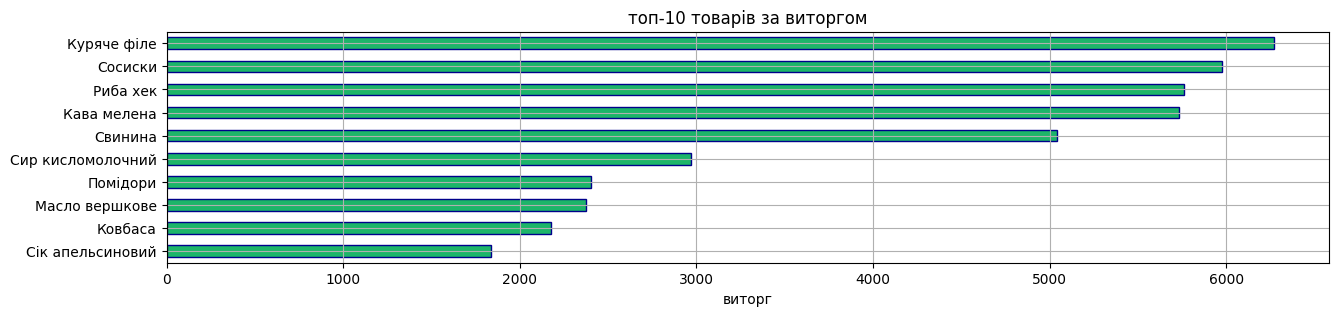

In [38]:
fig = plt.figure(figsize=(15, 3))
#
top_10_revenue = (
    df.groupby("product")["total_uah"]
    .sum()
    .sort_values(ascending=True)
    .tail(10)
    )
top_10_revenue.plot(
    kind="barh",
    color="#1db569",
    edgecolor="darkblue"
    )
plt.title("топ-10 товарів за виторгом")
plt.xlabel("виторг")
plt.ylabel("")
plt.grid()
plt.show()

5.3.Кругова діаграма - розподіл способів оплати.

In [39]:
fig = plt.figure()
payment_count = df.payment.value_counts()

#fig.pie(payment_count)


<Figure size 640x480 with 0 Axes>

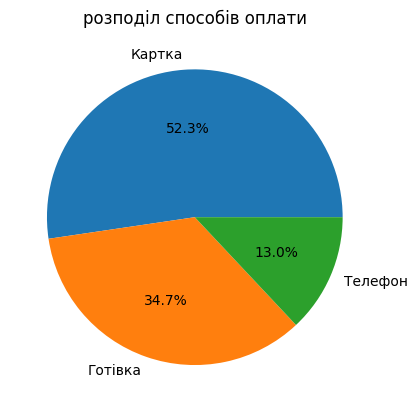

In [40]:
fig, ax = plt.subplots()
payment_count = df.payment.value_counts()
ax.pie(payment_count, labels=payment_count.index, autopct='%1.1f%%')
ax.set_title('розподіл способів оплати')
plt.show()

5.4.Лінійний графік - виторг по днях березня.

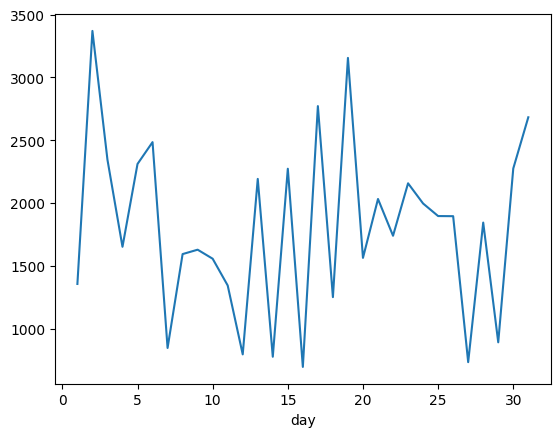

In [41]:
df.groupby("day")["total_uah"].sum().plot(kind="line")

plt.show()

In [42]:
pivot = df.groupby(["day", "category"])["total_uah"].sum().unstack()
pivot["total_sum_day"] = pivot.sum(axis=1)
pivot.loc["total_sum_category"] = pivot.sum(axis=0)
pivot.tail(5)

category,М'ясо та риба,Молочне,Напої,Овочі та фрукти,Хліб та випічка,total_sum_day
day,,,,,,
28,330.0,926.0,465.0,15.0,108.0,1844.0
29,578.0,180.0,NaN,NaN,132.0,890.0
30,1470.0,294.0,175.0,90.0,246.0,2275.0
31,1958.0,690.0,35.0,NaN,NaN,2683.0
total_sum_category,25223.0,10075.0,10389.0,6270.0,4134.0,56091.0


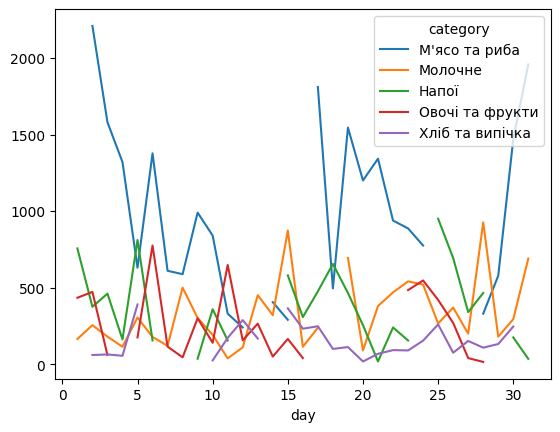

In [43]:
df.groupby(["day", "category"])["total_uah"].sum().unstack().plot(kind="line")
plt.show()

In [44]:
pd.pivot_table(
    df,
    values="total_uah",
    index="day",
    columns="category",
    aggfunc="sum",
    margins=True,
    margins_name="total_sum"
)

category,М'ясо та риба,Молочне,Напої,Овочі та фрукти,Хліб та випічка,total_sum
day,,,,,,
1,NaN,165.0,756.0,434.0,NaN,1355
2,2209.0,255.0,375.0,472.0,60.0,3371
3,1580.0,180.0,461.0,60.0,64.0,2345
4,1320.0,114.0,162.0,NaN,55.0,1651
5,630.0,305.0,811.0,175.0,390.0,2311
6,1377.0,178.0,155.0,775.0,NaN,2485
7,610.0,120.0,NaN,115.0,NaN,845
8,588.0,500.0,NaN,45.0,460.0,1593
9,990.0,302.0,36.0,300.0,NaN,1628


5.5.Гістограма - розподіл customer_age.

In [45]:
df.customer_age.value_counts()

,count
customer_age,
28,10
32,10
37,10
58,9
20,9
25,9
19,8
46,8
29,8


In [46]:
df.customer_age.value_counts()

,count
customer_age,
28,10
32,10
37,10
58,9
20,9
25,9
19,8
46,8
29,8


[22. 14. 25. 20. 21. 24. 17. 21. 17. 22. 23. 20. 18. 16. 20.]
[18.  21.4 24.8 28.2 31.6 35.  38.4 41.8 45.2 48.6 52.  55.4 58.8 62.2
 65.6 69. ]
<BarContainer object of 15 artists>


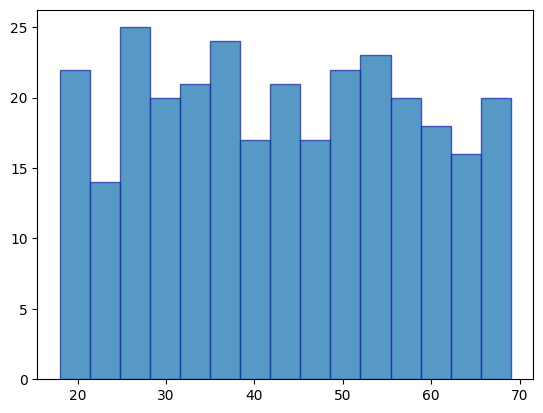

In [47]:
df["customer_age"].value_counts().mean()
counts, bins, patches = plt.hist(
    df["customer_age"],
    bins=15,
    #color="",
    edgecolor="#162ea6",
    alpha=0.75
)
print(counts)
print(bins)
print(patches)
plt.show()

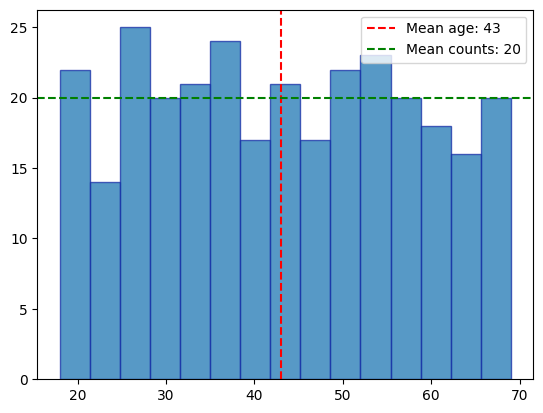

In [48]:
counts, bins, patches = plt.hist(
    df["customer_age"],
    bins=15,
    #color="",
    edgecolor="#162ea6",
    alpha=0.75 # transparent
)
# vertical - h
plt.axvline(
    df["customer_age"].mean(),
    color="red",
    linestyle="--",
    label=f"Mean age: {df["customer_age"].mean():.0f}"
)
# horisontal - v
plt.axhline(
    counts.mean(),
    color="green",
    linestyle="--",
    label=f"Mean counts: {counts.mean():.0f}"
)
plt.legend()
plt.show()

<Figure size 800x300 with 0 Axes>

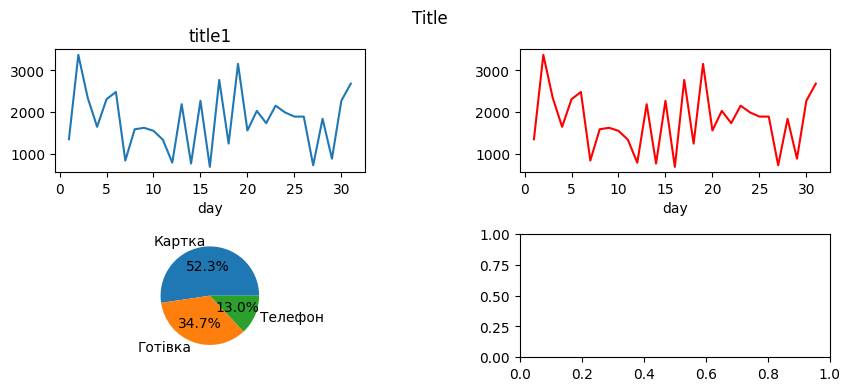

In [49]:
plt.figure(figsize=(8, 3))
fig, axes = plt.subplots(2, 2, figsize=(10, 4))
fig.suptitle("Title")
plt.subplots_adjust(hspace=0.5, wspace=0.5)

ax1 = axes[0, 0]
ax1.set_title("title1")
ax1.set_xlabel("bins age")
df.groupby('day')['total_uah'].sum().plot(kind='line', ax=ax1)
ax2 = axes[0, 1]
df.groupby('day')['total_uah'].sum().plot(kind='line', color="red", ax=ax2)
ax3 = axes[1, 0]
payment_count = df.payment.value_counts()
ax3.pie(payment_count, labels=payment_count.index, autopct='%1.1f%%')
plt.savefig('figure.png')
plt.show()

In [50]:
df.columns

Index(['transaction_id', 'date', 'hour', 'category', 'product', 'quantity',
       'price_uah', 'customer_age', 'payment', 'total_uah', 'day',
       'revenue_share', 'age_group', 'weekday', 'is_big_purchase'],
      dtype='object')

# Блок 6 - Фінальні висновки


```
Яка категорія товарів найприбутковіша?
В які години найактивніша торгівля?
Який спосіб оплати переважає?
Чи є «пікові» дні продажів?
Хто типовий покупець (вік, що купує, як платить)?
```

In [57]:
# Яка категорія товарів найприбутковіша?
print(f"Hайприбутковіша категорія товарів: '{df.groupby('category')['total_uah'].sum().idxmax()}'")

Hайприбутковіша категорія товарів: 'М'ясо та риба'


In [63]:
# В які години найактивніша торгівля?
display(df.groupby("hour").size().nlargest(3))
print(f"\nHайактивніша торгівля o {df.groupby("hour").size().idxmax()} годині")


,0
hour,
14,44
13,41
16,32



Hайактивніша торгівля o 14 годині


In [66]:
# Який спосіб оплати переважає?
print(f'Cпосіб оплати, що переважає: "{df.groupby('payment')['transaction_id'].count().idxmax()}"')

Cпосіб оплати, що переважає: "Картка"


In [75]:
# Чи є «пікові» дні продажів?
daily_sales = df.groupby('date')['total_uah'].sum()
threshold = daily_sales.mean() + daily_sales.std()

print(f"«пікові» дні продажів:")
print(daily_sales[daily_sales > threshold].sort_values(ascending=False))

«пікові» дні продажів:
date
2024-03-02    3371
2024-03-19    3156
2024-03-17    2772
2024-03-31    2683
Name: total_uah, dtype: int64


In [106]:
# Хто типовий покупець (вік, що купує, як платить)?
typical_age = df["customer_age"].mode().max()
typical_payment = df["payment"].mode()[0]
avg_check = df["total_uah"].mean()
top_category = df["category"].mode()[0]

print(f'''
1.Типовий покупець магазину:
- вікова група - '{typical_age} років'
- Спосіб оплати - '{typical_payment}'
- Середній чек - '{avg_check} грн.'
2. Найприбутковіша категорія - '{top_category}'
3. Найактивніші години продажів - о {df.groupby("hour").size().idxmax()}:00 годині
''')




1.Типовий покупець магазину:
- вікова група - '37 років'
- Спосіб оплати - 'Картка' 
- Середній чек - '186.97 грн.' 
2. Найприбутковіша категорія - 'Молочне'   
3. Найактивніші години продажів - о 14:00 годині

